Cell 1: Install and import libraries

In [ ]:
!pip -q install torchsummary

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import random
import time
import copy

Cell 2: Set random seed and device

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


Cell 3: Load CIFAR-10 with same split as earlier problems

In [ ]:
batch_size = 128

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_full_aug = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

train_full_clean = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=test_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

num_train = len(train_full_aug)
indices = np.arange(num_train)

np.random.seed(SEED)
np.random.shuffle(indices)

train_size = 45000

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full_aug, train_indices)
val_dataset = Subset(train_full_clean, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

classes = test_dataset.classes

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", classes)

100%|██████████| 170M/170M [00:04<00:00, 41.8MB/s]


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Cell 4: Helper function for parameter count

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Cell 5: Define ResNet BasicBlock

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # Shortcut connection
        # If the size or number of channels changes, use 1x1 conv to match dimensions.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out

Cell 6: Define ResNet for CIFAR-10

In [ ]:
class ResNetCIFAR(nn.Module):
    def __init__(self, block, layers, num_classes=10, dropout_p=0.0):
        super(ResNetCIFAR, self).__init__()

        self.in_channels = 64
        self.dropout_p = dropout_p

        # CIFAR-10 stem: 3x3 conv, no max pool
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Four residual stages
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Dropout after global average pooling
        self.dropout = nn.Dropout(p=dropout_p)

        # Final classifier
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []

        # First block in the stage may downsample
        layers.append(
            block(
                self.in_channels,
                out_channels,
                stride=stride
            )
        )

        self.in_channels = out_channels * block.expansion

        # Remaining blocks keep same dimensions
        for _ in range(1, num_blocks):
            layers.append(
                block(
                    self.in_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)

        out = self.dropout(out)

        out = self.fc(out)

        return out

Cell 7: Define ResNet-11, ResNet-18, and ResNet-34

In [ ]:
def ResNet11(dropout_p=0.0):
    # 1 stem conv + 5 BasicBlocks × 2 convs = 11 main convolution layers
    return ResNetCIFAR(
        block=BasicBlock,
        layers=[1, 1, 1, 2],
        num_classes=10,
        dropout_p=dropout_p
    )

def ResNet18(dropout_p=0.0):
    # Standard ResNet-18 structure: four stages, two BasicBlocks per stage
    return ResNetCIFAR(
        block=BasicBlock,
        layers=[2, 2, 2, 2],
        num_classes=10,
        dropout_p=dropout_p
    )

def ResNet34(dropout_p=0.0):
    # Bonus model
    return ResNetCIFAR(
        block=BasicBlock,
        layers=[3, 4, 6, 3],
        num_classes=10,
        dropout_p=dropout_p
    )

Cell 8: Check model summaries and parameter counts

In [ ]:
resnet11_check = ResNet11(dropout_p=0.0).to(device)
resnet18_check = ResNet18(dropout_p=0.0).to(device)

print("ResNet-11 parameters:", count_parameters(resnet11_check))
print("ResNet-18 parameters:", count_parameters(resnet18_check))

ResNet-11 parameters: 9623882
ResNet-18 parameters: 11173962


In [ ]:
summary(resnet18_check, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
          Identity-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
       BasicBlock-11           [-1, 64, 32, 32]               0
         Identity-12           [-1, 64, 32, 32]               0
           Conv2d-13           [-1, 64, 32, 32]          36,864
      BatchNorm2d-14           [-1, 64,

Cell 9: Training function

In [ ]:
def train_one_model(model, train_loader, val_loader, epochs=50, lr=0.001, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train

        model.eval()

        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = 100 * correct_val / total_val

        epoch_time = time.time() - epoch_start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.2f}% "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.2f}% "
            f"Time: {epoch_time:.2f}s"
        )

    total_time = time.time() - total_start_time

    print("Training complete.")
    print("Best validation accuracy:", best_val_acc)
    print("Average time per epoch:", np.mean(history["epoch_time"]))
    print("Total training time in minutes:", total_time / 60)

    model.load_state_dict(best_model_wts)

    return model, history, best_val_acc

Cell 10: Test evaluation function

In [ ]:
def evaluate_on_test(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct / total

    return test_acc, np.array(all_labels), np.array(all_preds)

Cell 11: Plotting functions

In [ ]:
def plot_single_history(history, title):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Training Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_loss_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="Training Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title + " Accuracy Curves")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_accuracy_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
def compare_histories(histories, labels, title):
    epochs_range = range(1, len(histories[0]["train_loss"]) + 1)

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["train_loss"], label=f"{label} Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title(title + " Training Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_train_loss_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["val_loss"], label=f"{label} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(title + " Validation Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_val_loss_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["val_acc"], label=f"{label} Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title(title + " Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)
    plt.savefig(title.replace(" ", "_") + "_val_accuracy_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
def plot_confusion_matrix(labels, preds, title):
    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(10, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d"
    )

    plt.title(title)
    plt.savefig(title.replace(" ", "_") + ".png", dpi=300, bbox_inches="tight")
    plt.show()

Part A: ResNet-11 vs ResNet-18

In [ ]:
epochs = 50
learning_rate = 0.001
weight_decay = 0.0

Cell 12: Train ResNet-11 baseline

In [ ]:
resnet11_baseline_model = ResNet11(dropout_p=0.0).to(device)

resnet11_baseline_model, resnet11_baseline_history, resnet11_baseline_best_val_acc = train_one_model(
    resnet11_baseline_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/50] Train Loss: 1.4445 Train Acc: 47.06% Val Loss: 1.2102 Val Acc: 57.14% Time: 33.27s
Epoch [2/50] Train Loss: 1.0011 Train Acc: 64.32% Val Loss: 0.8988 Val Acc: 68.32% Time: 28.94s
Epoch [3/50] Train Loss: 0.7904 Train Acc: 72.14% Val Loss: 0.9460 Val Acc: 70.06% Time: 29.94s
Epoch [4/50] Train Loss: 0.6669 Train Acc: 76.46% Val Loss: 0.7263 Val Acc: 75.30% Time: 30.74s
Epoch [5/50] Train Loss: 0.5855 Train Acc: 79.60% Val Loss: 0.6283 Val Acc: 79.22% Time: 30.00s
Epoch [6/50] Train Loss: 0.5137 Train Acc: 82.10% Val Loss: 0.5789 Val Acc: 80.64% Time: 30.43s
Epoch [7/50] Train Loss: 0.4651 Train Acc: 83.99% Val Loss: 0.5253 Val Acc: 82.58% Time: 30.63s
Epoch [8/50] Train Loss: 0.4307 Train Acc: 84.99% Val Loss: 0.5109 Val Acc: 83.48% Time: 30.14s
Epoch [9/50] Train Loss: 0.3935 Train Acc: 86.23% Val Loss: 0.4602 Val Acc: 84.72% Time: 30.66s
Epoch [10/50] Train Loss: 0.3574 Train Acc: 87.44% Val Loss: 0.4524 Val Acc: 85.80% Time: 30.02s
Epoch [11/50] Train Loss: 0.3369 Train 

Cell 13: Test ResNet-11 baseline

In [ ]:
resnet11_baseline_test_acc, resnet11_baseline_labels, resnet11_baseline_preds = evaluate_on_test(
    resnet11_baseline_model,
    test_loader
)

print("ResNet-11 baseline test accuracy:", resnet11_baseline_test_acc)

ResNet-11 baseline test accuracy: 91.92


Cell 14: Plot ResNet-11 baseline results

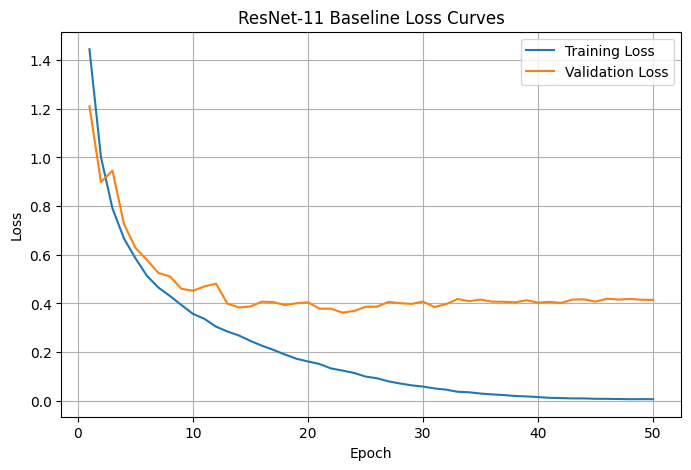

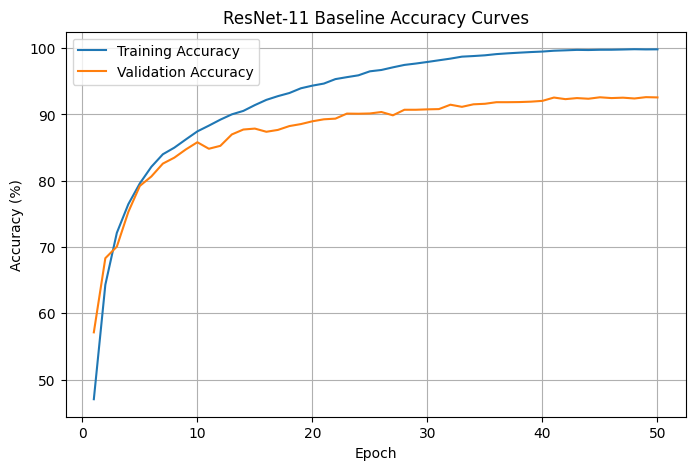

In [ ]:
plot_single_history(
    resnet11_baseline_history,
    "ResNet-11 Baseline"
)

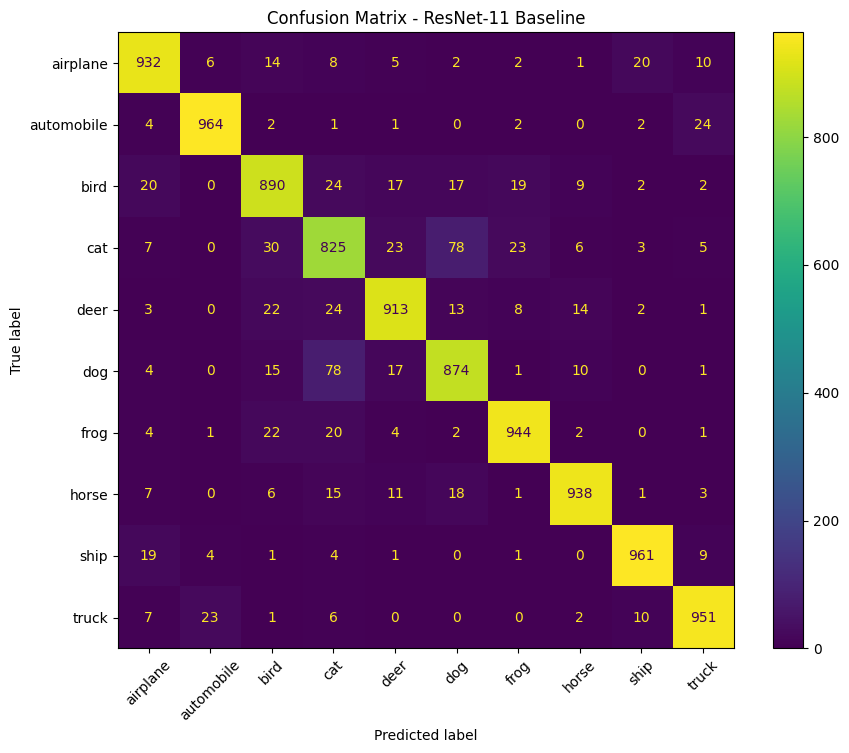

In [ ]:
plot_confusion_matrix(
    resnet11_baseline_labels,
    resnet11_baseline_preds,
    "Confusion Matrix - ResNet-11 Baseline"
)

Cell 15: Train ResNet-18 baseline

In [ ]:
resnet18_baseline_model = ResNet18(dropout_p=0.0).to(device)

resnet18_baseline_model, resnet18_baseline_history, resnet18_baseline_best_val_acc = train_one_model(
    resnet18_baseline_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/50] Train Loss: 1.4396 Train Acc: 47.10% Val Loss: 1.1545 Val Acc: 58.72% Time: 42.28s
Epoch [2/50] Train Loss: 0.9769 Train Acc: 65.10% Val Loss: 1.1023 Val Acc: 64.38% Time: 41.54s
Epoch [3/50] Train Loss: 0.7610 Train Acc: 73.23% Val Loss: 0.9177 Val Acc: 69.32% Time: 42.15s
Epoch [4/50] Train Loss: 0.6402 Train Acc: 77.75% Val Loss: 0.7079 Val Acc: 76.42% Time: 41.78s
Epoch [5/50] Train Loss: 0.5479 Train Acc: 80.89% Val Loss: 0.7640 Val Acc: 74.90% Time: 41.54s
Epoch [6/50] Train Loss: 0.4876 Train Acc: 83.21% Val Loss: 0.5287 Val Acc: 82.44% Time: 41.82s
Epoch [7/50] Train Loss: 0.4394 Train Acc: 84.77% Val Loss: 0.4790 Val Acc: 84.38% Time: 42.14s
Epoch [8/50] Train Loss: 0.3991 Train Acc: 86.16% Val Loss: 0.6018 Val Acc: 80.52% Time: 41.58s
Epoch [9/50] Train Loss: 0.3739 Train Acc: 87.02% Val Loss: 0.4871 Val Acc: 84.12% Time: 41.71s
Epoch [10/50] Train Loss: 0.3326 Train Acc: 88.41% Val Loss: 0.4874 Val Acc: 85.00% Time: 41.84s
Epoch [11/50] Train Loss: 0.3038 Train 

Cell 16: Test ResNet-18 baseline

In [ ]:
resnet18_baseline_test_acc, resnet18_baseline_labels, resnet18_baseline_preds = evaluate_on_test(
    resnet18_baseline_model,
    test_loader
)

print("ResNet-18 baseline test accuracy:", resnet18_baseline_test_acc)

ResNet-18 baseline test accuracy: 92.71


Cell 17: Plot ResNet-18 baseline results

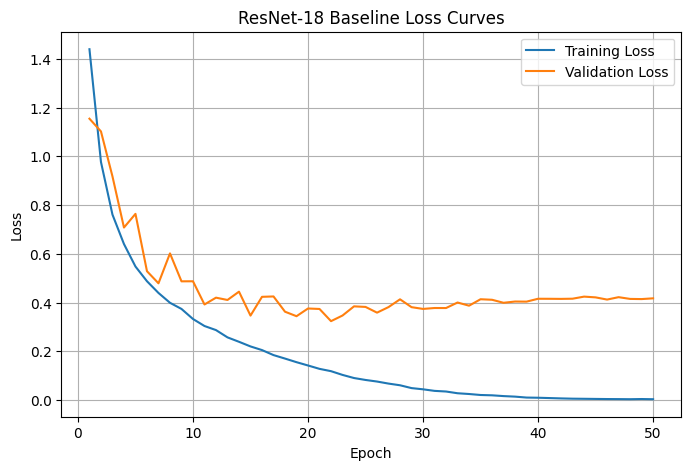

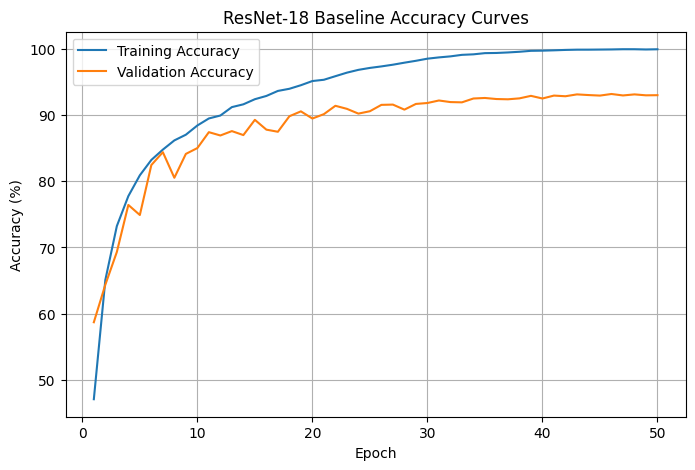

In [ ]:
plot_single_history(
    resnet18_baseline_history,
    "ResNet-18 Baseline"
)

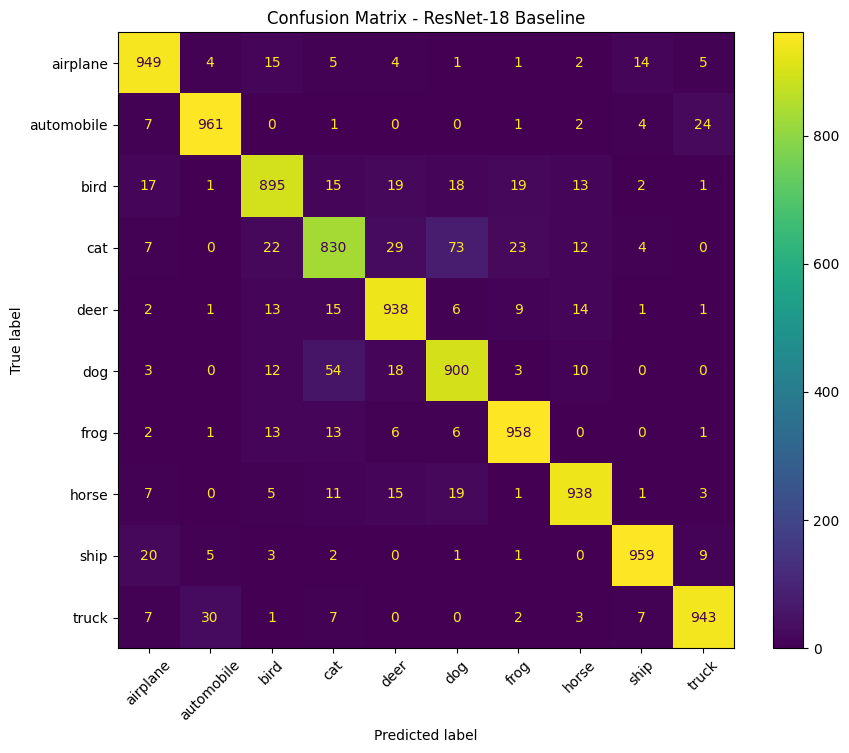

In [ ]:
plot_confusion_matrix(
    resnet18_baseline_labels,
    resnet18_baseline_preds,
    "Confusion Matrix - ResNet-18 Baseline"
)

Cell 18: Compare ResNet-11 and ResNet-18 baseline curves

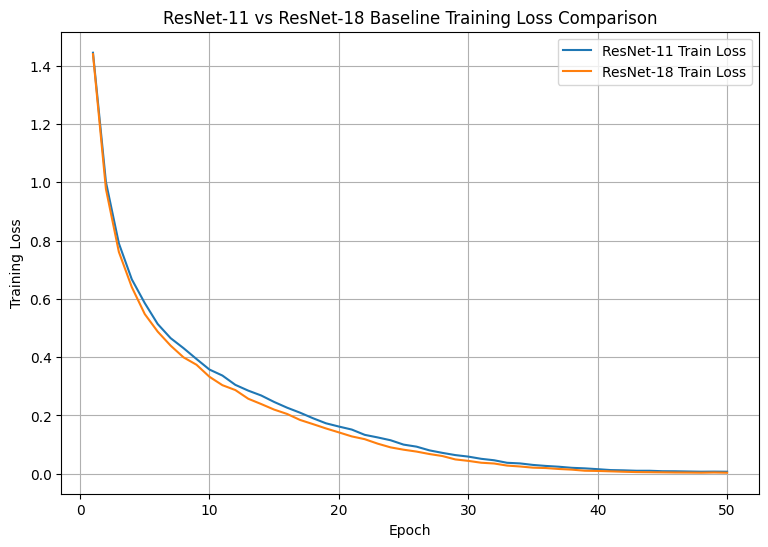

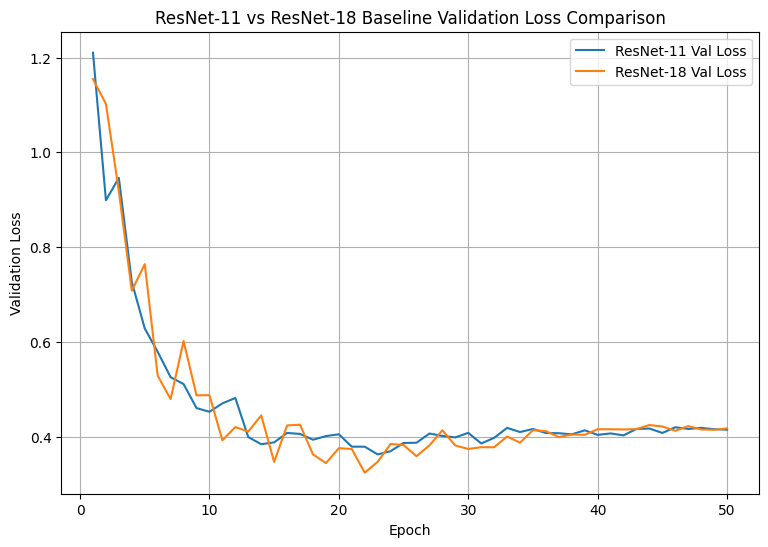

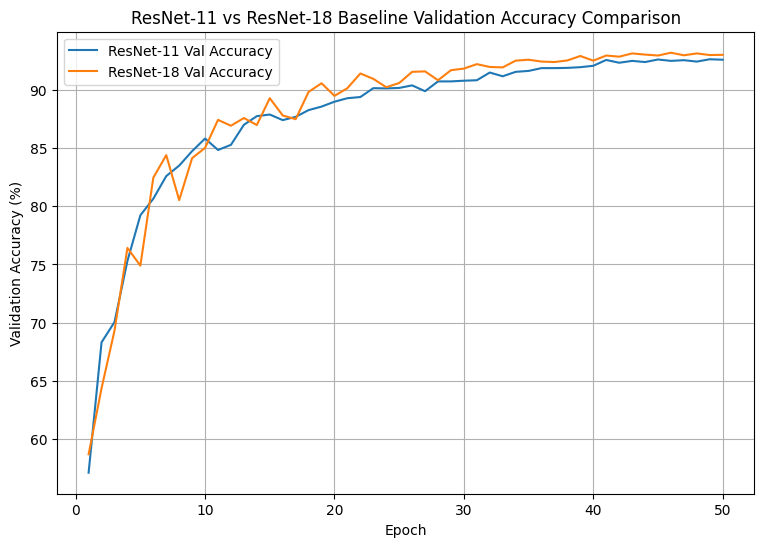

In [ ]:
compare_histories(
    histories=[
        resnet11_baseline_history,
        resnet18_baseline_history
    ],
    labels=[
        "ResNet-11",
        "ResNet-18"
    ],
    title="ResNet-11 vs ResNet-18 Baseline"
)

Cell 19: ResNet-11 vs ResNet-18 baseline comparison table

In [ ]:
resnet_baseline_comparison = {
    "Model": [
        "ResNet-11 Baseline",
        "ResNet-18 Baseline"
    ],
    "Parameters": [
        count_parameters(resnet11_baseline_model),
        count_parameters(resnet18_baseline_model)
    ],
    "Best Validation Accuracy (%)": [
        max(resnet11_baseline_history["val_acc"]),
        max(resnet18_baseline_history["val_acc"])
    ],
    "Test Accuracy (%)": [
        resnet11_baseline_test_acc,
        resnet18_baseline_test_acc
    ],
    "Average Time Per Epoch (s)": [
        np.mean(resnet11_baseline_history["epoch_time"]),
        np.mean(resnet18_baseline_history["epoch_time"])
    ]
}

resnet_baseline_df = pd.DataFrame(resnet_baseline_comparison)
resnet_baseline_df

,Model,Parameters,Best Validation Accuracy (%),Test Accuracy (%),Average Time Per Epoch (s)
0,ResNet-11 Baseline,9623882,92.60,91.92,30.315363
1,ResNet-18 Baseline,11173962,93.16,92.71,41.786635


Part B: Dropout on ResNet-11 and ResNet-18

Cell 20: Train ResNet-11 with dropout p = 0.3

In [28]:
resnet11_dropout03_model = ResNet11(dropout_p=0.3).to(device)

resnet11_dropout03_model, resnet11_dropout03_history, resnet11_dropout03_best_val_acc = train_one_model(
    resnet11_dropout03_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/50] Train Loss: 1.4772 Train Acc: 45.86% Val Loss: 1.2798 Val Acc: 55.46% Time: 29.84s
Epoch [2/50] Train Loss: 1.0092 Train Acc: 63.76% Val Loss: 0.9733 Val Acc: 66.28% Time: 32.40s
Epoch [3/50] Train Loss: 0.8150 Train Acc: 71.03% Val Loss: 0.9314 Val Acc: 68.78% Time: 31.71s
Epoch [4/50] Train Loss: 0.6856 Train Acc: 75.93% Val Loss: 0.7600 Val Acc: 75.00% Time: 29.95s
Epoch [5/50] Train Loss: 0.6017 Train Acc: 78.96% Val Loss: 0.6324 Val Acc: 79.14% Time: 34.48s
Epoch [6/50] Train Loss: 0.5385 Train Acc: 81.48% Val Loss: 0.6301 Val Acc: 78.56% Time: 33.61s
Epoch [7/50] Train Loss: 0.4848 Train Acc: 83.28% Val Loss: 0.5811 Val Acc: 80.78% Time: 32.64s
Epoch [8/50] Train Loss: 0.4439 Train Acc: 84.58% Val Loss: 0.5845 Val Acc: 81.96% Time: 31.41s
Epoch [9/50] Train Loss: 0.4086 Train Acc: 85.91% Val Loss: 0.4636 Val Acc: 84.80% Time: 31.33s
Epoch [10/50] Train Loss: 0.3742 Train Acc: 86.92% Val Loss: 0.4742 Val Acc: 84.28% Time: 30.72s
Epoch [11/50] Train Loss: 0.3426 Train 

In [ ]:
resnet11_dropout03_test_acc, resnet11_dropout03_labels, resnet11_dropout03_preds = evaluate_on_test(
    resnet11_dropout03_model,
    test_loader
)

print("ResNet-11 dropout p=0.3 test accuracy:", resnet11_dropout03_test_acc)

Cell 21: Train ResNet-11 with dropout p = 0.5

In [29]:
resnet11_dropout05_model = ResNet11(dropout_p=0.5).to(device)

resnet11_dropout05_model, resnet11_dropout05_history, resnet11_dropout05_best_val_acc = train_one_model(
    resnet11_dropout05_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/50] Train Loss: 1.5021 Train Acc: 45.16% Val Loss: 1.2973 Val Acc: 55.02% Time: 34.32s
Epoch [2/50] Train Loss: 1.0292 Train Acc: 63.18% Val Loss: 0.9763 Val Acc: 65.84% Time: 30.71s
Epoch [3/50] Train Loss: 0.8350 Train Acc: 70.67% Val Loss: 0.7866 Val Acc: 73.18% Time: 30.53s
Epoch [4/50] Train Loss: 0.7028 Train Acc: 75.57% Val Loss: 0.6704 Val Acc: 77.18% Time: 30.48s
Epoch [5/50] Train Loss: 0.6136 Train Acc: 78.80% Val Loss: 0.6719 Val Acc: 76.96% Time: 30.21s
Epoch [6/50] Train Loss: 0.5446 Train Acc: 81.06% Val Loss: 0.5601 Val Acc: 80.84% Time: 30.53s
Epoch [7/50] Train Loss: 0.4968 Train Acc: 83.04% Val Loss: 0.4974 Val Acc: 83.20% Time: 30.66s
Epoch [8/50] Train Loss: 0.4527 Train Acc: 84.34% Val Loss: 0.5539 Val Acc: 81.44% Time: 30.37s
Epoch [9/50] Train Loss: 0.4193 Train Acc: 85.59% Val Loss: 0.5045 Val Acc: 83.26% Time: 31.03s
Epoch [10/50] Train Loss: 0.3792 Train Acc: 86.84% Val Loss: 0.4488 Val Acc: 85.22% Time: 30.38s
Epoch [11/50] Train Loss: 0.3613 Train 

In [30]:
resnet11_dropout05_test_acc, resnet11_dropout05_labels, resnet11_dropout05_preds = evaluate_on_test(
    resnet11_dropout05_model,
    test_loader
)

print("ResNet-11 dropout p=0.5 test accuracy:", resnet11_dropout05_test_acc)

ResNet-11 dropout p=0.5 test accuracy: 91.5


Cell 22: Train ResNet-18 with dropout p = 0.3

In [32]:
 resnet18_dropout03_model = ResNet18(dropout_p=0.3).to(device)

resnet18_dropout03_model, resnet18_dropout03_history, resnet18_dropout03_best_val_acc = train_one_model(
    resnet18_dropout03_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/50] Train Loss: 1.5446 Train Acc: 43.28% Val Loss: 1.3407 Val Acc: 51.22% Time: 43.29s
Epoch [2/50] Train Loss: 1.0626 Train Acc: 61.95% Val Loss: 0.9369 Val Acc: 67.02% Time: 41.67s
Epoch [3/50] Train Loss: 0.8454 Train Acc: 70.05% Val Loss: 0.8786 Val Acc: 70.72% Time: 42.57s
Epoch [4/50] Train Loss: 0.6923 Train Acc: 75.81% Val Loss: 0.7059 Val Acc: 76.44% Time: 41.90s
Epoch [5/50] Train Loss: 0.6018 Train Acc: 78.90% Val Loss: 0.6566 Val Acc: 77.72% Time: 41.76s
Epoch [6/50] Train Loss: 0.5263 Train Acc: 82.04% Val Loss: 0.6767 Val Acc: 78.50% Time: 41.74s
Epoch [7/50] Train Loss: 0.4770 Train Acc: 83.44% Val Loss: 0.5575 Val Acc: 81.32% Time: 42.36s
Epoch [8/50] Train Loss: 0.4255 Train Acc: 85.25% Val Loss: 0.5983 Val Acc: 81.54% Time: 41.72s
Epoch [9/50] Train Loss: 0.3924 Train Acc: 86.41% Val Loss: 0.4474 Val Acc: 84.78% Time: 41.73s
Epoch [10/50] Train Loss: 0.3605 Train Acc: 87.64% Val Loss: 0.5409 Val Acc: 83.18% Time: 41.69s
Epoch [11/50] Train Loss: 0.3296 Train 

In [33]:
resnet18_dropout03_test_acc, resnet18_dropout03_labels, resnet18_dropout03_preds = evaluate_on_test(
    resnet18_dropout03_model,
    test_loader
)

print("ResNet-18 dropout p=0.3 test accuracy:", resnet18_dropout03_test_acc)

ResNet-18 dropout p=0.3 test accuracy: 92.8


Cell 23: Train ResNet-18 with dropout p = 0.5

In [36]:
resnet18_dropout05_model = ResNet18(dropout_p=0.5).to(device)

resnet18_dropout05_model, resnet18_dropout05_history, resnet18_dropout05_best_val_acc = train_one_model(
    resnet18_dropout05_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/50] Train Loss: 1.5671 Train Acc: 42.93% Val Loss: 1.3180 Val Acc: 53.06% Time: 43.79s
Epoch [2/50] Train Loss: 1.0889 Train Acc: 61.11% Val Loss: 1.0466 Val Acc: 64.00% Time: 41.74s
Epoch [3/50] Train Loss: 0.8881 Train Acc: 68.79% Val Loss: 0.8067 Val Acc: 70.88% Time: 42.01s
Epoch [4/50] Train Loss: 0.7503 Train Acc: 73.81% Val Loss: 0.7706 Val Acc: 74.52% Time: 42.11s
Epoch [5/50] Train Loss: 0.6370 Train Acc: 77.79% Val Loss: 1.1685 Val Acc: 66.86% Time: 41.92s
Epoch [6/50] Train Loss: 0.5620 Train Acc: 80.94% Val Loss: 0.6117 Val Acc: 79.56% Time: 41.75s
Epoch [7/50] Train Loss: 0.5080 Train Acc: 82.47% Val Loss: 0.4994 Val Acc: 83.32% Time: 41.54s
Epoch [8/50] Train Loss: 0.4589 Train Acc: 84.25% Val Loss: 0.6169 Val Acc: 80.66% Time: 42.35s
Epoch [9/50] Train Loss: 0.4230 Train Acc: 85.38% Val Loss: 0.5351 Val Acc: 82.66% Time: 41.68s
Epoch [10/50] Train Loss: 0.3833 Train Acc: 86.81% Val Loss: 0.5317 Val Acc: 83.30% Time: 41.57s
Epoch [11/50] Train Loss: 0.3522 Train 

In [37]:
resnet18_dropout05_test_acc, resnet18_dropout05_labels, resnet18_dropout05_preds = evaluate_on_test(
    resnet18_dropout05_model,
    test_loader
)

print("ResNet-18 dropout p=0.5 test accuracy:", resnet18_dropout05_test_acc)

ResNet-18 dropout p=0.5 test accuracy: 92.37


Cell 24: Compare ResNet dropout curves

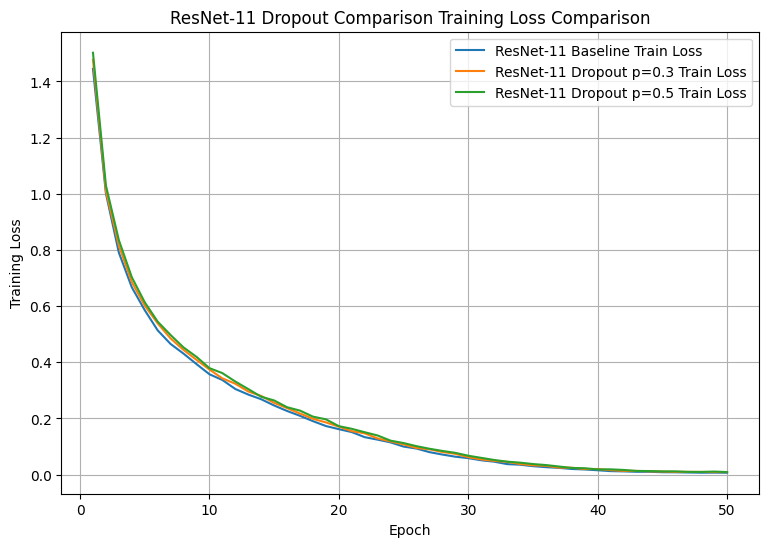

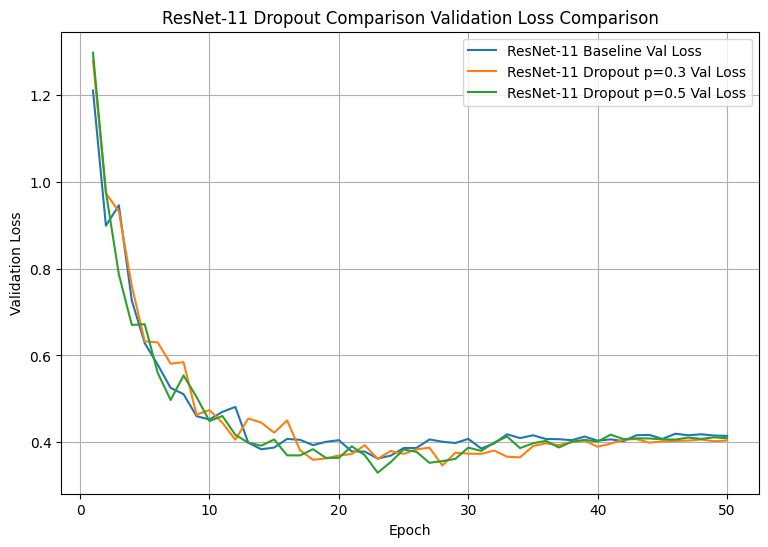

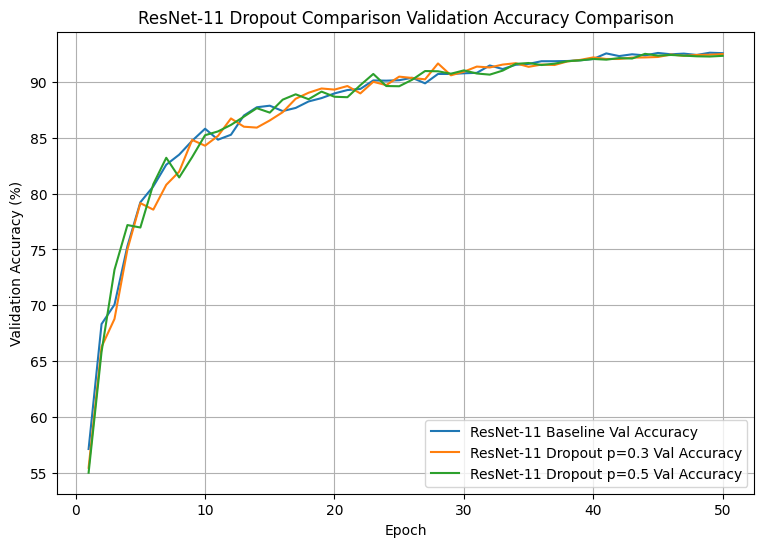

In [38]:
compare_histories(
    histories=[
        resnet11_baseline_history,
        resnet11_dropout03_history,
        resnet11_dropout05_history
    ],
    labels=[
        "ResNet-11 Baseline",
        "ResNet-11 Dropout p=0.3",
        "ResNet-11 Dropout p=0.5"
    ],
    title="ResNet-11 Dropout Comparison"
)

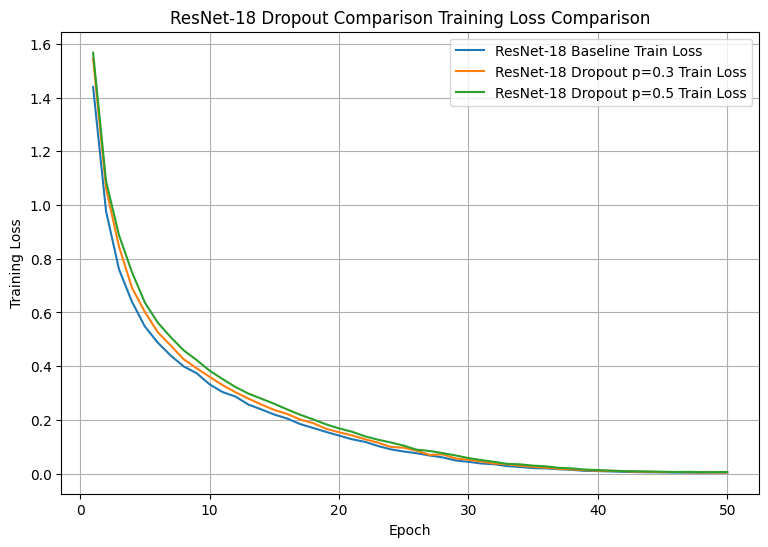

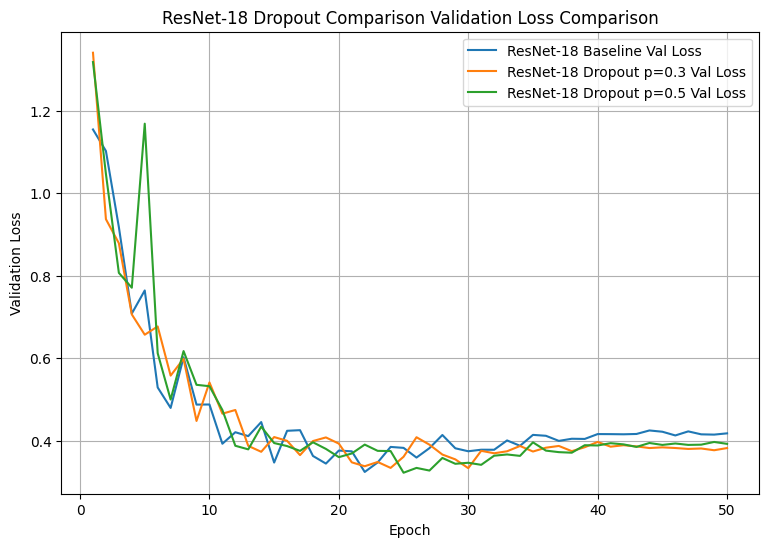

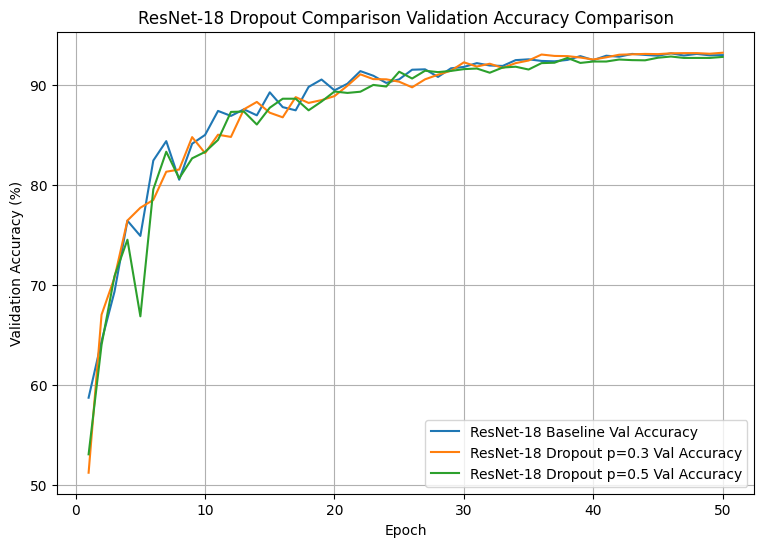

In [42]:
compare_histories(
    histories=[
        resnet18_baseline_history,
        resnet18_dropout03_history,
        resnet18_dropout05_history
    ],
    labels=[
        "ResNet-18 Baseline",
        "ResNet-18 Dropout p=0.3",
        "ResNet-18 Dropout p=0.5"
    ],
    title="ResNet-18 Dropout Comparison"
)

Cell 25: Full ResNet dropout table

In [43]:
resnet_dropout_results = {
    "Model": [
        "ResNet-11 Baseline",
        "ResNet-11 Dropout p=0.3",
        "ResNet-11 Dropout p=0.5",
        "ResNet-18 Baseline",
        "ResNet-18 Dropout p=0.3",
        "ResNet-18 Dropout p=0.5"
    ],
    "Parameters": [
        count_parameters(resnet11_baseline_model),
        count_parameters(resnet11_dropout03_model),
        count_parameters(resnet11_dropout05_model),
        count_parameters(resnet18_baseline_model),
        count_parameters(resnet18_dropout03_model),
        count_parameters(resnet18_dropout05_model)
    ],
    "Best Validation Accuracy (%)": [
        max(resnet11_baseline_history["val_acc"]),
        max(resnet11_dropout03_history["val_acc"]),
        max(resnet11_dropout05_history["val_acc"]),
        max(resnet18_baseline_history["val_acc"]),
        max(resnet18_dropout03_history["val_acc"]),
        max(resnet18_dropout05_history["val_acc"])
    ],
    "Test Accuracy (%)": [
        resnet11_baseline_test_acc,
        resnet11_dropout03_test_acc,
        resnet11_dropout05_test_acc,
        resnet18_baseline_test_acc,
        resnet18_dropout03_test_acc,
        resnet18_dropout05_test_acc
    ],
    "Average Time Per Epoch (s)": [
        np.mean(resnet11_baseline_history["epoch_time"]),
        np.mean(resnet11_dropout03_history["epoch_time"]),
        np.mean(resnet11_dropout05_history["epoch_time"]),
        np.mean(resnet18_baseline_history["epoch_time"]),
        np.mean(resnet18_dropout03_history["epoch_time"]),
        np.mean(resnet18_dropout05_history["epoch_time"])
    ]
}

resnet_dropout_df = pd.DataFrame(resnet_dropout_results)
resnet_dropout_df

NameError: name 'resnet11_dropout03_test_acc' is not defined

Cell 26: Find best ResNet-11 and best ResNet-18 variants

In [44]:
resnet11_variants = [
    {
        "name": "ResNet-11 Baseline",
        "model": resnet11_baseline_model,
        "history": resnet11_baseline_history,
        "test_acc": resnet11_baseline_test_acc
    },
    {
        "name": "ResNet-11 Dropout p=0.3",
        "model": resnet11_dropout03_model,
        "history": resnet11_dropout03_history,
        "test_acc": resnet11_dropout03_test_acc
    },
    {
        "name": "ResNet-11 Dropout p=0.5",
        "model": resnet11_dropout05_model,
        "history": resnet11_dropout05_history,
        "test_acc": resnet11_dropout05_test_acc
    }
]

resnet18_variants = [
    {
        "name": "ResNet-18 Baseline",
        "model": resnet18_baseline_model,
        "history": resnet18_baseline_history,
        "test_acc": resnet18_baseline_test_acc
    },
    {
        "name": "ResNet-18 Dropout p=0.3",
        "model": resnet18_dropout03_model,
        "history": resnet18_dropout03_history,
        "test_acc": resnet18_dropout03_test_acc
    },
    {
        "name": "ResNet-18 Dropout p=0.5",
        "model": resnet18_dropout05_model,
        "history": resnet18_dropout05_history,
        "test_acc": resnet18_dropout05_test_acc
    }
]

best_resnet11 = max(resnet11_variants, key=lambda x: x["test_acc"])
best_resnet18 = max(resnet18_variants, key=lambda x: x["test_acc"])

print("Best ResNet-11 variant:", best_resnet11["name"], best_resnet11["test_acc"])
print("Best ResNet-18 variant:", best_resnet18["name"], best_resnet18["test_acc"])

NameError: name 'resnet11_dropout03_test_acc' is not defined

Cell 27: Manual entries for AlexNet and VGGNet results

In [45]:
# Replace these numbers with your actual results from Problems 1 and 2.

best_alexnet_name = "Best AlexNet"
best_alexnet_params = 2438922          # Replace if your AlexNet parameter count is different
best_alexnet_test_acc = 0.0            # Put your actual best AlexNet test accuracy here
best_alexnet_time = 0.0                # Put your actual average time per epoch here

best_vgg_name = "Best VGGNet"
best_vgg_params = 0                    # Put your actual best VGG parameter count here
best_vgg_test_acc = 0.0                # Put your actual best VGG test accuracy here
best_vgg_time = 0.0                    # Put your actual average time per epoch here

Cell 28: Final comparison table

In [46]:
final_comparison = {
    "Architecture": [
        best_alexnet_name,
        best_vgg_name,
        best_resnet11["name"],
        best_resnet18["name"]
    ],
    "Parameter Count": [
        best_alexnet_params,
        best_vgg_params,
        count_parameters(best_resnet11["model"]),
        count_parameters(best_resnet18["model"])
    ],
    "Test Accuracy (%)": [
        best_alexnet_test_acc,
        best_vgg_test_acc,
        best_resnet11["test_acc"],
        best_resnet18["test_acc"]
    ],
    "Average Time Per Epoch (s)": [
        best_alexnet_time,
        best_vgg_time,
        np.mean(best_resnet11["history"]["epoch_time"]),
        np.mean(best_resnet18["history"]["epoch_time"])
    ]
}

final_comparison_df = pd.DataFrame(final_comparison)
final_comparison_df

NameError: name 'best_resnet11' is not defined

Cell 29: Bar chart of test accuracies

In [ ]:
plt.figure(figsize=(9, 6))
plt.bar(
    final_comparison_df["Architecture"],
    final_comparison_df["Test Accuracy (%)"]
)
plt.xlabel("Architecture")
plt.ylabel("Test Accuracy (%)")
plt.title("Best Model Test Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.savefig("Final_Test_Accuracy_Bar_Chart.png", dpi=300, bbox_inches="tight")
plt.show()

Bonus: ResNet-34

Cell 30: Train ResNet-34 bonus model

In [ ]:
resnet34_model = ResNet34(dropout_p=0.0).to(device)

print("ResNet-34 parameters:", count_parameters(resnet34_model))

resnet34_model, resnet34_history, resnet34_best_val_acc = train_one_model(
    resnet34_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

In [ ]:
resnet34_test_acc, resnet34_labels, resnet34_preds = evaluate_on_test(
    resnet34_model,
    test_loader
)

print("ResNet-34 test accuracy:", resnet34_test_acc)

In [ ]:
plot_single_history(
    resnet34_history,
    "ResNet-34 Bonus"
)

In [ ]:
plot_confusion_matrix(
    resnet34_labels,
    resnet34_preds,
    "Confusion Matrix - ResNet-34 Bonus"
)

Cell 31: Bonus ResNet comparison table

In [ ]:
bonus_resnet_comparison = {
    "Model": [
        "ResNet-11 Best",
        "ResNet-18 Best",
        "ResNet-34"
    ],
    "Parameters": [
        count_parameters(best_resnet11["model"]),
        count_parameters(best_resnet18["model"]),
        count_parameters(resnet34_model)
    ],
    "Test Accuracy (%)": [
        best_resnet11["test_acc"],
        best_resnet18["test_acc"],
        resnet34_test_acc
    ],
    "Average Time Per Epoch (s)": [
        np.mean(best_resnet11["history"]["epoch_time"]),
        np.mean(best_resnet18["history"]["epoch_time"]),
        np.mean(resnet34_history["epoch_time"])
    ]
}

bonus_resnet_df = pd.DataFrame(bonus_resnet_comparison)
bonus_resnet_df

End of Problem 3